In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 画图的主题设计
sns.set_theme()
sns.set_context('notebook')
data_user = pd.read_csv('/home/user1/pytorch_env/python_learn/data_analysis/user_action.csv')
 

In [3]:
# 加载数据
data_user = pd.read_csv('user_action.csv')
data_user.head(20)

,user_id,item_id,behavior_type,item_category,time
0,98047837,232431562,1,4245,2014-12-06 02
1,97726136,383583590,1,5894,2014-12-09 20
2,98607707,64749712,1,2883,2014-12-18 11
3,98662432,320593836,1,6562,2014-12-06 10
4,98145908,290208520,1,13926,2014-12-16 21
5,93784494,337869048,1,3979,2014-12-03 20
6,94832743,105749725,1,9559,2014-12-13 20
7,95290487,76866650,1,10875,2014-11-27 16
8,96610296,161166643,1,3064,2014-12-11 23
9,100684618,21751142,3,2158,2014-12-05 23


In [4]:
# 查看数据集量级
print('整体数据的大小为',len(data_user))

print('数据集中用户数量是：',len(set(data_user['user_id'])))
print('数据集中商品数量是：',len(set(data_user['item_id'])))
print('数据集中商品类别数量是：',len(set(data_user['item_category'])))


整体数据的大小为 12256906
数据集中用户数量是： 10000
数据集中商品数量是： 2876947
数据集中商品类别数量是： 8916


In [5]:
data_user.isnull().sum()

user_id          0
item_id          0
behavior_type    0
item_category    0
time             0
dtype: int64

In [6]:
data_user['date'] = data_user['time'].map(lambda x: x.split(' ')[0])
data_user['hour'] = data_user['time'].map(lambda x: x.split(' ')[1])
data_user.head()

,user_id,item_id,behavior_type,item_category,time,date,hour
0,98047837,232431562,1,4245,2014-12-06 02,2014-12-06,02
1,97726136,383583590,1,5894,2014-12-09 20,2014-12-09,20
2,98607707,64749712,1,2883,2014-12-18 11,2014-12-18,11
3,98662432,320593836,1,6562,2014-12-06 10,2014-12-06,10
4,98145908,290208520,1,13926,2014-12-16 21,2014-12-16,21


In [7]:
data_user.dtypes

user_id           int64
item_id           int64
behavior_type     int64
item_category     int64
time             object
date             object
hour             object
dtype: object

In [8]:
data_user['user_id'] = data_user['user_id'].astype('object')
data_user['item_id'] = data_user['item_id'].astype('object')
data_user['item_category'] = data_user['item_category'].astype('object')
data_user['date'] = pd.to_datetime(data_user['date'])
data_user['hour'] = data_user['hour'].astype('int64')


In [9]:
data_user.dtypes

user_id                  object
item_id                  object
behavior_type             int64
item_category            object
time                     object
date             datetime64[ns]
hour                      int64
dtype: object

关注访问量pv 每次对淘宝页面的刷新次数，用户每刷新一次页面或者打开新的页面就记录就算一次访问。 
和独立访问量uv 多次访问淘宝只记录一次 (SQL: SELECT DISTINCT user_id as uv FROM data_user)

In [10]:
pv_daily = data_user.groupby('date')['user_id'].count()
pv_daily.head()#date是索引

date
2014-11-18    366701
2014-11-19    358823
2014-11-20    353429
2014-11-21    333104
2014-11-22    361355
Name: user_id, dtype: int64

In [11]:
pv_daily = pv_daily.reset_index() 
pv_daily = pv_daily.rename(columns={'user_id':'pv_daily'})
pv_daily

,date,pv_daily
0,2014-11-18,366701
1,2014-11-19,358823
2,2014-11-20,353429
3,2014-11-21,333104
4,2014-11-22,361355
5,2014-11-23,382702
6,2014-11-24,378342
7,2014-11-25,370239
8,2014-11-26,360896
9,2014-11-27,371384


In [12]:
uv_daily = data_user.groupby('date')['user_id'].apply(lambda x:len(x.unique()))

In [13]:
uv_daily = uv_daily.reset_index()
uv_daily = uv_daily.rename(columns={'user_id':'uv_daily'})
uv_daily.head(20)

,date,uv_daily
0,2014-11-18,6343
1,2014-11-19,6420
2,2014-11-20,6333
3,2014-11-21,6276
4,2014-11-22,6187
5,2014-11-23,6373
6,2014-11-24,6513
7,2014-11-25,6351
8,2014-11-26,6357
9,2014-11-27,6359


Text(0.5, 1.0, 'uv_daily')

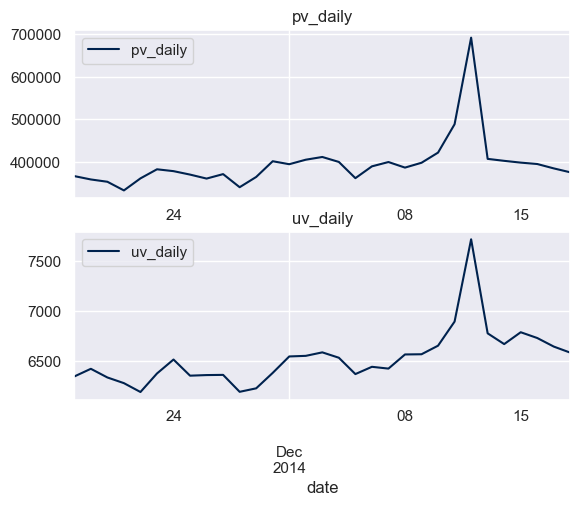

In [14]:
fig, axes = plt.subplots(2,1)
pv_daily.plot (x='date',y='pv_daily',ax=axes[0],colormap = 'cividis')
uv_daily.plot(x='date',y='uv_daily',ax=axes[1],colormap = 'cividis')
axes[0].set_title('pv_daily')
axes[1].set_title('uv_daily')


可以看出，不管是PV还是UV趋势，均在12号的时候出现了一个尖峰，这正是著名的双十二大促节的用户集中消费导致的变化。 通过简单的数据分析和可视化工具，这是我们从数据中观察到了第一个结论。

基于小时级别访问流量分析

In [15]:
pv_hour = data_user.groupby(['hour'])['user_id'].count()
pv_hour
pv_hour = pv_hour.reset_index()
pv_hour = pv_hour.rename(columns={'user_id':'pv_hour'})
pv_hour


,hour,pv_hour
0,0,517404
1,1,267682
2,2,147090
3,3,98516
4,4,80487
5,5,88296
6,6,158798
7,7,287337
8,8,396106
9,9,485951


In [16]:
uv_hour = data_user.groupby('hour')['user_id'].apply(lambda x: len(x.unique()))
uv_hour = uv_hour.reset_index()
uv_hour = uv_hour.rename(columns={'user_id':'uv_hour'})
uv_hour

,hour,uv_hour
0,0,5786
1,1,3780
2,2,2532
3,3,1937
4,4,1765
5,5,2030
6,6,3564
7,7,5722
8,8,7108
9,9,7734


Text(0.5, 1.0, 'uv_hour')

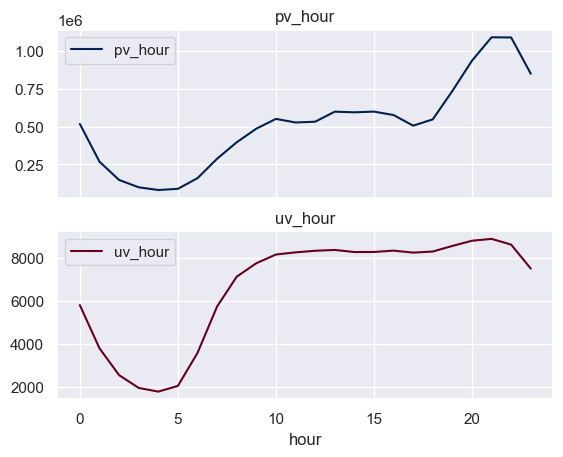

In [17]:
# 可视化
fig, axes = plt.subplots(2,1,sharex=True)
pv_hour.plot(x='hour',y='pv_hour',ax=axes[0],colormap='cividis')
uv_hour.plot(x='hour', y='uv_hour', ax=axes[1],colormap='RdGy')
axes[0].set_title('pv_hour')
axes[1].set_title('uv_hour')

In [18]:
data_user_1212 = data_user.loc[data_user['date']=='2014-12-12']
data_user_1212.dtypes

user_id                  object
item_id                  object
behavior_type             int64
item_category            object
time                     object
date             datetime64[ns]
hour                      int64
dtype: object

In [19]:
pv_hour_1212 = data_user_1212.groupby('hour')['user_id'].count().reset_index().rename(columns={'user_id':'1212_pv_hour'})
uv_hour_1212 = data_user_1212.groupby('hour')['user_id'].apply(lambda x: len(x.unique())).reset_index().rename(columns={'user_id':'1212_uv_hour'})
pv_hour_1212
uv_hour_1212

,hour,1212_uv_hour
0,0,1569
1,1,811
2,2,411
3,3,255
4,4,211
5,5,264
6,6,679
7,7,1296
8,8,1712
9,9,1827


Text(0.5, 1.0, 'pv_hour_1212')

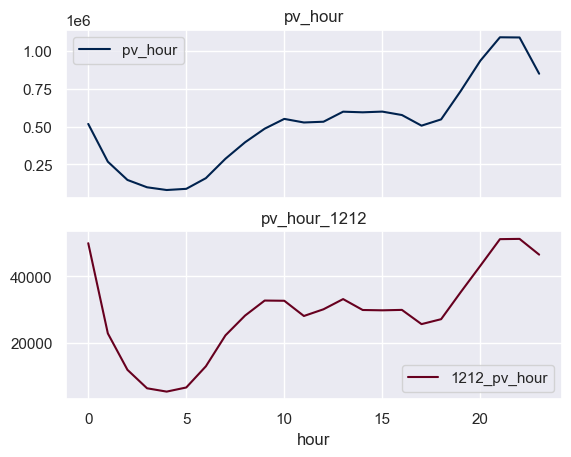

In [20]:
# 可视化PV
fig, axes = plt.subplots(2,1,sharex=True)
pv_hour.plot(x='hour',y='pv_hour',ax=axes[0],colormap='cividis')
pv_hour_1212.plot(x='hour', y='1212_pv_hour', ax=axes[1],colormap='RdGy')
axes[0].set_title('pv_hour')
axes[1].set_title('pv_hour_1212')

双十二当天，PV变化趋与一个月内的PV变化趋势基本一致，只不过曲线不太平滑，多出来小的凸点，一个可能的原因是大促当天，有整点领券活动，通过推送等形式会有效拉动用户使用淘宝。UV变化趋势稍有不同，可以看到双十二当天在晚上8点之后UV出现了小高峰，表明了大促当天用户的消费意愿还是比较强烈。

In [21]:
pv_behavior = data_user.groupby(['behavior_type','hour'])['user_id'].count().reset_index().rename(columns={'user_id':'pv_behavior_hour'})
pv_behavior

,behavior_type,hour,pv_behavior_hour
0,1,0,487341
1,1,1,252991
2,1,2,139139
3,1,3,93250
4,1,4,75832
...,...,...,...
91,4,19,6352
92,4,20,7872
93,4,21,8829
94,4,22,8845


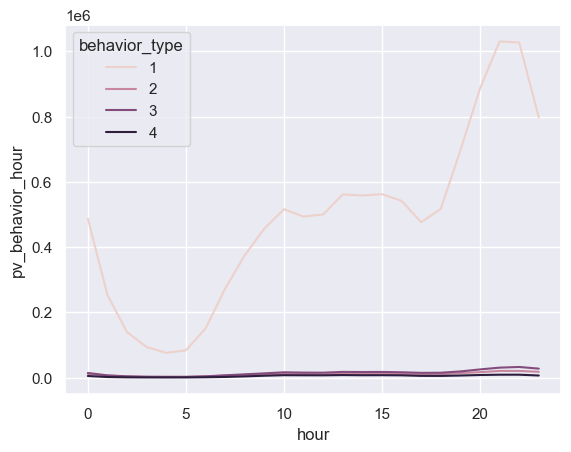

In [22]:
ax = sns.lineplot(x='hour',y='pv_behavior_hour',hue='behavior_type',data=pv_behavior)


因为action_type为1（浏览行为）的占比非常大，导致上图其它几类action的趋势不太明显，我们去掉action_type为1的数据后再来看看：

<Axes: xlabel='hour', ylabel='pv_behavior_hour'>

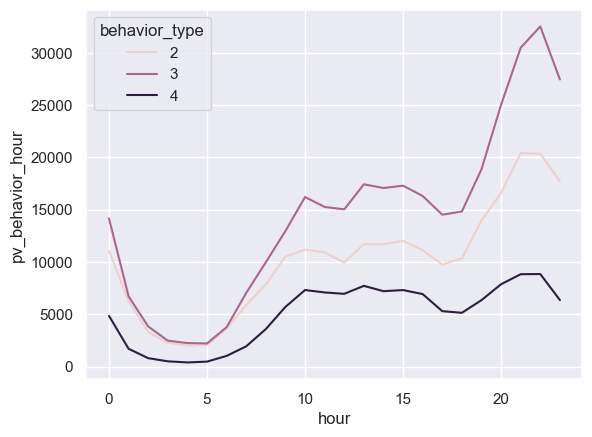

In [23]:
sns.lineplot(x='hour',y='pv_behavior_hour',hue='behavior_type',data=pv_behavior[pv_behavior.behavior_type!=1])

In [24]:
pv_behavior_hour_1212 = data_user_1212.groupby(['behavior_type','hour'])['user_id'].count().reset_index().rename(columns={'user_id':'1212_pv_hour'})
uv_behavior_hour_1212 = data_user_1212.groupby(['behavior_type','hour'])['user_id'].apply(lambda x: len(x.unique())).reset_index().rename(columns={'user_id':'1212_uv_hour'})
pv_behavior_hour_1212
uv_behavior_hour_1212

,behavior_type,hour,1212_uv_hour
0,1,0,1505
1,1,1,789
2,1,2,399
3,1,3,246
4,1,4,205
...,...,...,...
91,4,19,303
92,4,20,344
93,4,21,414
94,4,22,463


<Axes: xlabel='hour', ylabel='1212_pv_hour'>

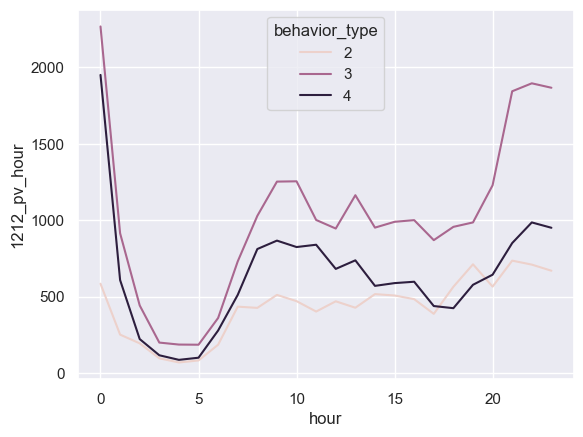

In [25]:
sns.lineplot(
    x='hour',
    y='1212_pv_hour',   # ✔ 用列名
    hue='behavior_type',
    data=pv_behavior_hour_1212[pv_behavior_hour_1212.behavior_type != 1]
)

针对性的进行营销活动，如推送优惠劵等，大家也可以留意下日常使用电商类App的推送通知的推送时间，一般都是在用户高峰期来做推送，可进一步促进转化率。

Part2. 转化率分析
我们来分析“浏览-收藏/加购-购买”链路的转化漏斗模型，可以帮助我们更好的了解各个环节的转化链路：

In [26]:
behavior_type = data_user.groupby('behavior_type')['user_id'].count()


In [27]:
click_num, fav_num, add_num, pay_num =  behavior_type[1], behavior_type[2], behavior_type[3], behavior_type[4]

fav_add_num = fav_num + add_num 
print('加购/收藏转化率：', 100 * fav_add_num / click_num,'%')
print('点击 到 购买转化率: ', 100 * pay_num / click_num)
print('加购/收藏 到 购买转化率: ', 100 * pay_num / fav_add_num)

加购/收藏转化率： 5.074376778103197 %
点击 到 购买转化率:  1.0406835811982098
加购/收藏 到 购买转化率:  20.508598921722513


In [28]:
behavior_type = data_user_1212.groupby(['behavior_type'])['user_id'].count()

click_num_1212, fav_num_1212, add_num_1212, pay_num_1212 =  behavior_type[1], behavior_type[2], behavior_type[3], behavior_type[4]

fav_add_num_1212 = fav_num_1212 + add_num_1212 
print('双十二 加购/收藏转化率：', 100 * fav_add_num_1212 / click_num_1212,'%')
print('双十二 点击 到 购买转化率: ', 100 * pay_num_1212 / click_num_1212)
print('双十二 加购/收藏 到 购买转化率: ', 100 * pay_num_1212 / fav_add_num_1212)


双十二 加购/收藏转化率： 5.448732437837779 %
双十二 点击 到 购买转化率:  2.3773707847303305
双十二 加购/收藏 到 购买转化率:  43.631630142472964


双十二当天，加购/收藏 到 购买转化率是平时的2倍之多，此外，加购/收藏 的转化率也比平时高出不少，说明大促的运营活动对用户活跃度的转化起到了很好的促进作用。

用户价值分析
在分析完整体变化趋势和转化率之后，商家更关注的是用户行为，什么用户是有价值的，什么用户是潜在用户？商业上已经有不少成熟的模型可供参考，如用户价值RFM分析模型等在用户购买行为的角度来探索用户价值：用户购买频次分析


In [30]:
data_user_buy = data_user[data_user.behavior_type==4].groupby('user_id')['behavior_type'].count()


<Axes: xlabel='user_id'>

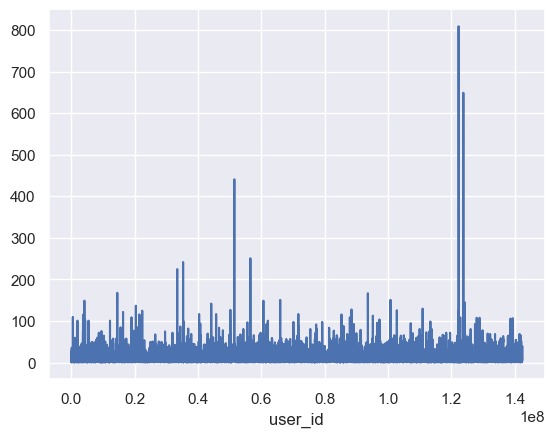

In [31]:
data_user_buy.plot(x='user_id', y='buy_count')

 ARPU = 每日消费总次数 / 每日活跃用户数

In [ ]:
data_user['action'] = 1
data_user_arpu = data_user.groupby(['date','user_id','behavior_type'])['action'].count().reset_index()
data_user_arpu.head(20) #action:用户每日的登录次数



,date,user_id,behavior_type,action
0,2014-11-18,4913,1,27
1,2014-11-18,4913,2,1
2,2014-11-18,7591,1,4
3,2014-11-18,12645,1,25
4,2014-11-18,54056,1,13
5,2014-11-18,54056,2,1
6,2014-11-18,54056,4,1
7,2014-11-18,79824,1,40
8,2014-11-18,79824,4,2
9,2014-11-18,88930,1,75


In [43]:
arpu = data_user_arpu.groupby('date').apply(lambda x:x[x['behavior_type']==4]['action'].sum()/len(x['user_id'].unique()))
# x['behavior_type']==4: 这通常是一个过滤器。在常见的电商数据集中（如阿里天池数据集），4 往往代表“支付”或“购买”行为。
# ['action']: 选取金额列。这里的 action 字段代表的是购买数量（比如购买了多少件），那么该公式算的是“人均购买量”
# sum(): 对选中的列进行求和操作，得到每个日期的购买总次数。
arpu.head(25)


/tmp/ipykernel_7763/813651666.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arpu = data_user_arpu.groupby('date').apply(lambda x:x[x['behavior_type']==4]['action'].sum()/len(x['user_id'].unique()))


date
2014-11-18    0.588050
2014-11-19    0.574143
2014-11-20    0.546660
2014-11-21    0.481358
2014-11-22    0.577016
2014-11-23    0.525184
2014-11-24    0.526025
2014-11-25    0.545426
2014-11-26    0.562058
2014-11-27    0.577135
2014-11-28    0.519955
2014-11-29    0.515906
2014-11-30    0.566860
2014-12-01    0.597341
2014-12-02    0.552824
2014-12-03    0.589977
2014-12-04    0.565151
2014-12-05    0.521282
2014-12-06    0.508075
2014-12-07    0.507007
2014-12-08    0.520871
2014-12-09    0.525282
2014-12-10    0.483464
2014-12-11    0.467943
2014-12-12    1.975518
dtype: float64

Text(0.5, 1.0, 'ARPU')

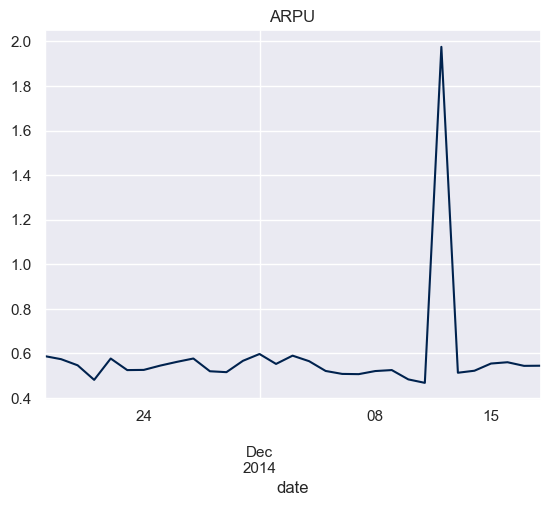

In [45]:
arpu.plot(colormap = 'cividis')
plt.title('ARPU')

下单率

In [ ]:
arpu1= data_user_arpu.groupby('date').apply(
    lambda x: len(x[x['behavior_type']==4]['user_id'].unique()) / len(x['user_id'].unique())
)
# x['behavior_type']==4: 这通常是一个过滤器。在常见的电商数据集中（如阿里天池数据集），4 往往代表“支付”或“购买”行为。
# ['user_id'].unique()) 代表的是 购买的用户数量
#  len(x['user_id'].unique())活跃用户数
arpu1.head(25)

/tmp/ipykernel_7763/3114030150.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arpu1= data_user_arpu.groupby('date').apply(


date
2014-11-18    0.242630
2014-11-19    0.235358
2014-11-20    0.235591
2014-11-21    0.211918
2014-11-22    0.228059
2014-11-23    0.225326
2014-11-24    0.233994
2014-11-25    0.235711
2014-11-26    0.233915
2014-11-27    0.240132
2014-11-28    0.232994
2014-11-29    0.221240
2014-11-30    0.240477
2014-12-01    0.253209
2014-12-02    0.241985
2014-12-03    0.257707
2014-12-04    0.242689
2014-12-05    0.234490
2014-12-06    0.225466
2014-12-07    0.218468
2014-12-08    0.236289
2014-12-09    0.217636
2014-12-10    0.216777
2014-12-11    0.210183
2014-12-12    0.504793
dtype: float64

从每位付费用户中获得的收益ARPPU = 总收入/活跃用户付费数量

In [71]:
arppu = data_user[data_user['behavior_type']==4].groupby(['user_id','date'])['behavior_type'].count()
arppu = arppu.reset_index().rename(columns={'behavior_type':'buy_count'})

In [61]:
arppu


,user_id,date,buy_count
0,4913,2014-12-01,1
1,4913,2014-12-07,2
2,4913,2014-12-11,1
3,4913,2014-12-13,1
4,4913,2014-12-16,1
...,...,...,...
49196,142455899,2014-11-24,1
49197,142455899,2014-11-26,2
49198,142455899,2014-11-30,1
49199,142455899,2014-12-03,1


In [72]:
arppu = arppu.groupby('date').apply(lambda x:x['buy_count'].sum() / x['user_id'].count())
arppu

/tmp/ipykernel_7763/2907228147.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arppu = arppu.groupby('date').apply(lambda x:x['buy_count'].sum() / x['user_id'].count())


date
2014-11-18    2.423652
2014-11-19    2.439444
2014-11-20    2.320375
2014-11-21    2.271429
2014-11-22    2.530120
2014-11-23    2.330780
2014-11-24    2.248031
2014-11-25    2.313961
2014-11-26    2.402824
2014-11-27    2.403405
2014-11-28    2.231623
2014-11-29    2.331881
2014-11-30    2.357236
2014-12-01    2.359083
2014-12-02    2.284543
2014-12-03    2.289334
2014-12-04    2.328707
2014-12-05    2.223041
2014-12-06    2.253444
2014-12-07    2.320741
2014-12-08    2.204384
2014-12-09    2.413576
2014-12-10    2.230236
2014-12-11    2.226363
2014-12-12    3.913523
2014-12-13    2.245320
2014-12-14    2.312749
2014-12-15    2.313460
2014-12-16    2.285455
2014-12-17    2.302548
2014-12-18    2.310567
dtype: float64

Text(0.5, 1.0, 'ARPPU')

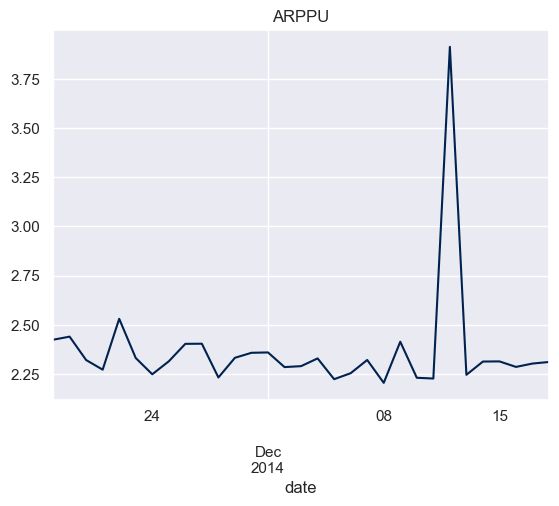

In [73]:
arppu.plot(colormap='cividis')
plt.title('ARPPU')

复购

In [74]:
# 计算用户购买频次
data_user_pay = data_user[data_user.behavior_type==4]
# 基于date去重，得到的结果即为购物分布的天数：
data_user_pay = data_user_pay.groupby('user_id')['date'].apply(lambda x: len(x.unique()))

data_user_pay

user_id
4913         5
6118         1
7528         6
7591         9
12645        4
            ..
142376113    1
142412247    7
142430177    5
142450275    8
142455899    7
Name: date, Length: 8886, dtype: int64

In [75]:
# 计算复购率：
repeat_buy_ratio = data_user_pay[data_user_pay > 1].count() / data_user_pay.count()
repeat_buy_ratio

np.float64(0.8717083051991897)

In [77]:
data_user['action'] = 1 # 对每一行的行为记为1次，通过对行为次数的相加，从而计算频次
data_user_buy = data_user[data_user.behavior_type == 4]
data_user_buy = data_user_buy.groupby(['user_id','date'])['action'].count()
data_user_buy = data_user_buy.reset_index()
data_user_buy.head(30)

,user_id,date,action
0,4913,2014-12-01,1
1,4913,2014-12-07,2
2,4913,2014-12-11,1
3,4913,2014-12-13,1
4,4913,2014-12-16,1
5,6118,2014-12-17,1
6,7528,2014-11-22,1
7,7528,2014-11-26,1
8,7528,2014-11-27,1
9,7528,2014-11-30,1


In [80]:
data_user_buy_date_diff = data_user_buy.groupby('user_id').date.apply(lambda x:x.sort_values().diff(1).dropna())

data_user_buy_date_diff.head(30)

user_id    
4913     1     6 days
         2     4 days
         3     2 days
         4     3 days
7528     7     4 days
         8     1 days
         9     3 days
         10    3 days
         11   10 days
7591     13    7 days
         14    1 days
         15    1 days
         16    2 days
         17    4 days
         18    1 days
         19    1 days
         20    1 days
12645    22    2 days
         23    4 days
         24   11 days
54056    26   19 days
79824    29    9 days
         30    8 days
         31    6 days
         32    1 days
         33    1 days
         34    3 days
88930    36    2 days
         37    2 days
         38    1 days
Name: date, dtype: timedelta64[ns]

计算的结果，第1列为索引列，即为user_id列； 第二列为该条记录在原始dataframe表中的索引位置，即data_user_buy的默认索引，第三列为同一用户相邻两个购买日期的求差结果。

Text(0, 0.5, 'count')

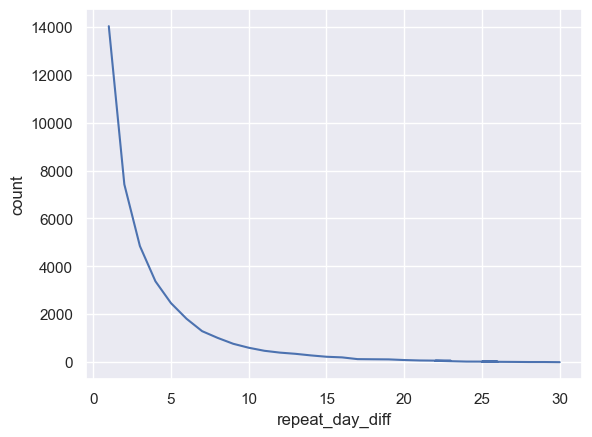

In [87]:
data_user_buy_date_diff.value_counts().plot(kind='line')

plt.xlabel('repeat_day_diff')
plt.ylabel('count')


小于6天的时候覆购率比较高

/tmp/ipykernel_7763/2054061994.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_user_buy_date_diff.reset_index().groupby('user_id').date.mean())


<Axes: xlabel='date', ylabel='Density'>

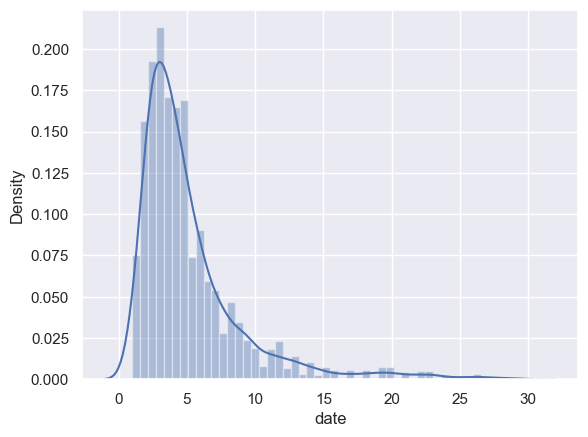

In [88]:
sns.distplot(data_user_buy_date_diff.reset_index().groupby('user_id').date.mean())

In [89]:
from datetime import datetime
datenow=datetime(2014,12,20)
#每位用户最近购买时间
recent_buy_time=data_user[data_user.behavior_type==4].groupby('user_id').date.apply(lambda x:datetime(2014,12,20)-x.sort_values().iloc[-1]).reset_index().rename(columns={'date':'recent'})
recent_buy_time.recent=recent_buy_time.recent.map(lambda x:x.days)

2️⃣ 计算 Recency（最近一次购买间隔）
recent_buy_time = data_user[data_user.behavior_type==4] \
    .groupby('user_id').date \
    .apply(lambda x: datetime(2014,12,20) - x.sort_values().iloc[-1]) \
    .reset_index().rename(columns={'date':'recent'})
核心逻辑：
behavior_type == 4：筛选出“购买行为”
groupby('user_id')：按用户分组
x.sort_values().iloc[-1]：取该用户最后一次购买时间
用 datenow - 最后购买时间 得到时间差（timedelta）

👉 此时 recent 是一个 timedelta 类型（例如：5 days）

转换为天数：
recent_buy_time.recent = recent_buy_time.recent.map(lambda x: x.days)

把 timedelta 转成整数天数，例如：

5 days → 5

👉 Recency 越小越好（说明最近刚买过）

3️⃣ 计算 Frequency（购买频率）
buy_freq = data_user[data_user.behavior_type==4] \
    .groupby('user_id').date.count() \
    .reset_index().rename(columns={'date':'freq'})
含义：
统计每个用户的购买次数
count() = 该用户购买行为的总次数

👉 freq 越大越好（说明用户更活跃）

4️⃣ 合并 R 和 F
rfm = pd.merge(recent_buy_time, buy_freq, on='user_id', how='outer')

得到结构：

user_id | recent | freq
5️⃣ 分箱打分（关键步骤）
rfm['recent_value'] = pd.qcut(rfm.recent, 2, labels=['2','1'])
rfm['freq_value']   = pd.qcut(rfm.freq, 2, labels=['1','2'])
🔹 qcut 含义

按分位数切分（等人数分组）

🔸 Recency 打分逻辑：
labels=['2','1']
最近（天数小） → 分数 2（好）
很久没买 → 分数 1（差）

👉 因为 recency 越小越好，所以标签是反的

🔸 Frequency 打分逻辑：
labels=['1','2']
购买少 → 1
购买多 → 2

👉 freq 越大越好

6️⃣ 拼接 RFM 标签
rfm['rfm'] = rfm['recent_value'].str.cat(rfm['freq_value'])

得到类似：

recent_value freq_value → rfm
      2            2     → "22"
      2            1     → "21"
      1            2     → "12"
      1            1     → "11"
7️⃣ rfm.head()

展示结果：

user_id | recent | freq | recent_value | freq_value | rfm

In [91]:
#每个用户消费频率
buy_freq=data_user[data_user.behavior_type==4].groupby('user_id').date.count().reset_index().rename(columns={'date':'freq'})
rfm=pd.merge(recent_buy_time,buy_freq,left_on='user_id',right_on='user_id',how='outer')
#将各维度分成两个程度,分数越高越好
rfm['recent_value']=pd.qcut(rfm.recent,2,labels=['2','1'])
rfm['freq_value']=pd.qcut(rfm.freq,2,labels=['1','2'])
rfm['rfm']=rfm['recent_value'].str.cat(rfm['freq_value'])
rfm.head(20)

,user_id,recent,freq,recent_value,freq_value,rfm
0,4913,4,6,2,1,21
1,6118,3,1,2,1,21
2,7528,7,6,1,1,11
3,7591,7,21,1,2,12
4,12645,6,8,2,1,21
5,54056,13,2,1,1,11
6,63348,9,1,1,1,11
7,79824,4,13,2,2,22
8,88930,3,23,2,2,22
9,100539,4,18,2,2,22
